# Lending Club Loan Performance & Risk Analysis (2007–2018)

Peer-to-peer lending platforms must carefully balance credit risk management with loan portfolio profitability. Ineffective risk assessment can lead to higher default rates, reduced investor confidence, and lower financial sustainability.

Lending institutions therefore need to better understand how borrower characteristics, loan attributes, and financial behavior influence loan performance and default risk.

Using historical lending data from Lending Club (2007–2018), this project analyzes loan outcomes to uncover patterns in borrower profiles, loan characteristics, and repayment behavior.

The objective is to generate data-driven insights that can help lending companies:

- Identify high-risk borrower profiles

- Understand the relationship between loan characteristics and default rates

- Evaluate the profitability of different loan segments

- Support better credit risk and lending strategy decisions

The analysis uses Python for data cleaning and exploratory analysis, SQL for business queries, and Power BI to create an interactive dashboard for financial insights.

---

## Connecting dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/cleaned_data.csv'

---

## Exploratory Data Analysis (EDA)

### Default distribution by purpose group

                    total  defaults  default_rate
purpose_group                                    
Business            16777      5229      0.311677
Health/Education    16225      3788      0.233467
Other               79791     18301      0.229362
Debt              1095457    234854      0.214389
Consumer            66159     13155      0.198839
Home                96756     19088      0.197280


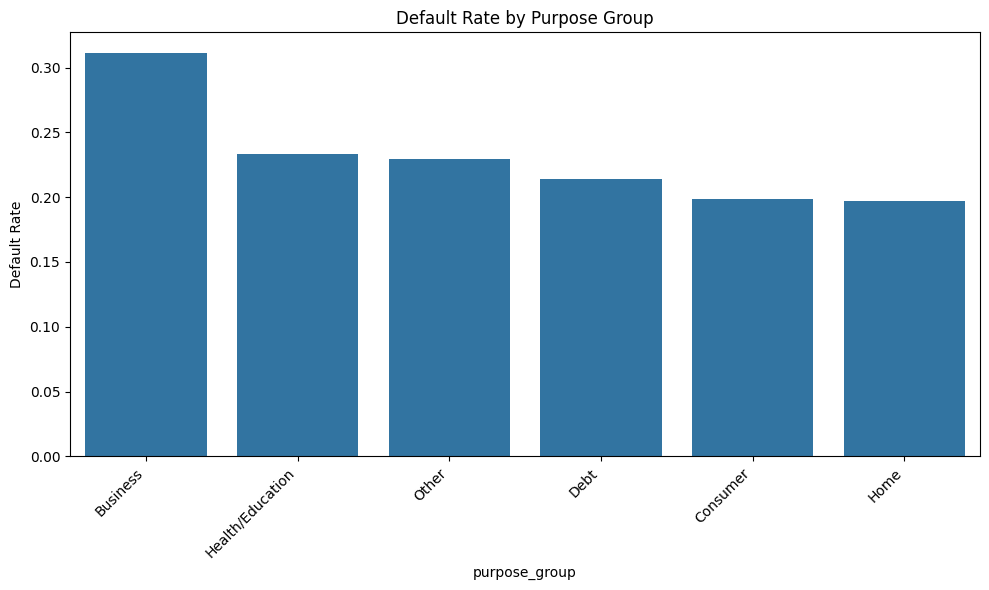

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

purpose_default = (df
    .groupby('purpose_group')['default']
    .agg(total='count', defaults='sum')
    .assign(default_rate=lambda x: x['defaults'] / x['total'])
    .sort_values('default_rate', ascending=False)
)

print(purpose_default)

plt.figure(figsize=(10, 6))
sns.barplot(data=purpose_default.reset_index(), x='purpose_group', y='default_rate')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Default Rate')
plt.title('Default Rate by Purpose Group')
plt.tight_layout()
plt.show()

### Default distribution by grade

        total  defaults  default_rate
grade                                
A      236758     15869      0.067026
B      398528     58357      0.146431
C      390724     94687      0.242337
D      206696     66797      0.323165
E       96224     38609      0.401241
F       32828     15261      0.464878
G        9407      4835      0.513979


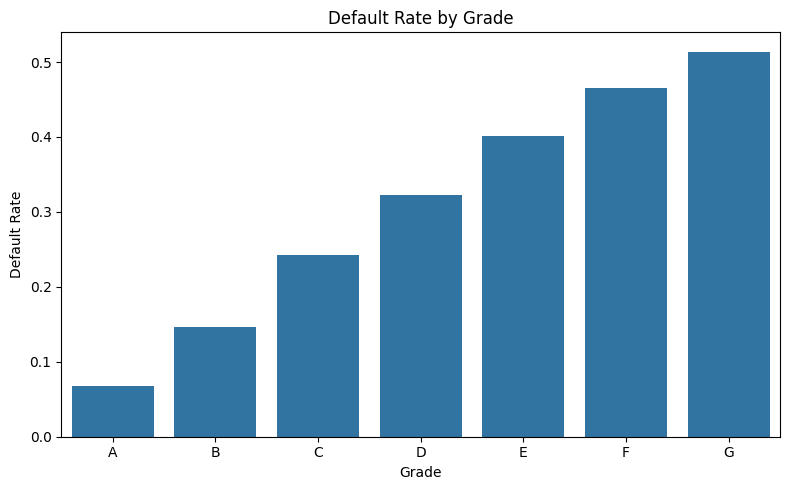

In [ ]:
grade_default = (df
    .groupby('grade')['default']
    .agg(total='count', defaults='sum')
    .assign(default_rate=lambda x: x['defaults'] / x['total'])
)

print(grade_default)

plt.figure(figsize=(8, 5))
sns.barplot(data=grade_default.reset_index(), x='grade', y='default_rate', order=sorted(df['grade'].dropna().unique()))
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')
plt.tight_layout()
plt.show()